# 10 — Multimodal Sequence + Text → Function Text Generation

---

### Goal
Train a **multimodal** model that takes a protein's **ESM2 sequence embedding** (1280-dim) **and SBERT text embedding** (384-dim) during training, and **generates a natural-language description** of its function — including GO terms, keywords, and subfamily.

At **inference** on new sequences (no text available), the model gracefully degrades to sequence-only mode thanks to **modality dropout** during training.

---

### Architecture (Prot2Text + LLaVA-inspired, Multimodal)

```
┌──────────────────────┐     ┌───────────────────────┐
│ ESM2 Embedding       │     │ SBERT Text Embedding   │
│ (1280-dim)           │     │ (384-dim)              │
│ ← pre-computed       │     │ ← pre-computed         │
└─────────┬────────────┘     └──────────┬─────────────┘
          ↓                             ↓
   Sequence Projector            Text Projector
   MLP: 1280 → 8×512            MLP: 384 → 4×512
          ↓                             ↓
     8 soft tokens               4 soft tokens
          └─────────┬───────────────────┘
                    ↓
         [12 encoder tokens]  ← T5 cross-attends here
                    ↓
         Flan-T5-small Decoder (LoRA on q,v)
                    ↓
         Generated Function Text
```

### Modality Dropout
During training, **20% of samples** have their text embedding zeroed out. This forces the model to learn robust sequence representations while still leveraging text when available.

---

### Key References
| Paper | Contribution | Relevance |
|:------|:------------|:----------|
| **Prot2Text** (Abdine et al., AAAI 2024) | ESM2 encoder + GPT-2 decoder for protein→text | Core architecture idea |
| **LLaVA** (Liu et al., NeurIPS 2023) | MLP projector bridging frozen encoder + LLM | Projector design |
| **Prefix-Tuning** (Li & Liang, ACL 2021) | Soft continuous prefix tokens | Soft token injection |
| **LoRA** (Hu et al., ICLR 2022) | Low-rank adapters for efficient fine-tuning | Parameter-efficient training |

In [3]:
# ============================================================
#  Install Dependencies
# ============================================================
!pip install -q transformers peft datasets evaluate rouge-score nltk accelerate sentencepiece protobuf

import warnings
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ============================================================
#  Imports
# ============================================================
import os, re, json, math, random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    get_linear_schedule_with_warmup,
)
from transformers.modeling_outputs import BaseModelOutput
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
import nltk

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# ── Style ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device : {DEVICE}")
print(f"✓ PyTorch: {torch.__version__}")

✓ Device : cpu
✓ PyTorch: 2.10.0+cpu


In [ ]:
# ============================================================
#  Configuration
# ============================================================
CONFIG = {
    # ── Paths ──
    "data_csv":        "../data/processed/final_multimodal_clusters.csv",
    "seq_emb_csv":     "../data/processed/embedding_sequences_mean_pooling.csv",
    "text_emb_npy":    "../data/processed/embeddings_sbert.npy",
    "text_order_csv":  "../data/processed/uniprot_all_fields_cache.csv",   # row order of SBERT
    "output_dir":      "../results/prot2func_gpcr_output",

    # ── Model ──
    "llm_model":         "google/flan-t5-small",   # 80 M params — CPU-friendly
    "seq_embedding_dim":  1280,                     # ESM2-650M mean-pooled
    "text_embedding_dim": 384,                      # SBERT (all-MiniLM-L6-v2)
    "num_seq_tokens":     8,                        # soft tokens from sequence projector
    "num_text_tokens":    4,                        # soft tokens from text projector

    # ── Training — Stage 1 (alignment: projectors only, T5 frozen) ──
    "stage1_epochs":  5,
    "stage1_lr":      1e-3,
    "stage1_batch":   16,

    # ── Training — Stage 2 (generation: projectors + LoRA) ──
    "stage2_epochs":  20,
    "stage2_lr":      3e-4,
    "stage2_batch":   8,

    # ── LoRA ──
    "lora_r":       16,
    "lora_alpha":   32,
    "lora_dropout": 0.1,

    # ── Modality Dropout ──
    "text_dropout_prob": 0.2,  # probability of zeroing text embedding during training

    # ── Tokenizer ──
    "max_target_len": 256,

    # ── Data ──
    "val_ratio": 0.15,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

print("=" * 60)
print("  CONFIGURATION")
print("=" * 60)
for k, v in CONFIG.items():
    print(f"  • {k:<25s}: {v}")

  CONFIGURATION
  • data_csv                 : ../data/processed/final_multimodal_clusters.csv
  • seq_emb_csv              : ../data/processed/embedding_sequences_mean_pooling.csv
  • text_emb_npy             : ../data/processed/embeddings_sbert.npy
  • text_order_csv           : ../data/processed/uniprot_all_fields_cache.csv
  • output_dir               : prot2func_gpcr_output
  • llm_model                : google/flan-t5-small
  • seq_embedding_dim        : 1280
  • text_embedding_dim       : 384
  • num_seq_tokens           : 8
  • num_text_tokens          : 4
  • stage1_epochs            : 5
  • stage1_lr                : 0.001
  • stage1_batch             : 16
  • stage2_epochs            : 20
  • stage2_lr                : 0.0003
  • stage2_batch             : 8
  • lora_r                   : 16
  • lora_alpha               : 32
  • lora_dropout             : 0.1
  • text_dropout_prob        : 0.2
  • max_target_len           : 256
  • val_ratio                : 0.15


---

## Step 1 — Load Data & Build Target Texts

We load **three** data sources and align them by protein ID:

| Source | Shape | Description |
|:-------|:------|:------------|
| `final_multimodal_clusters.csv` | 1 037 × 9 | Text annotations (GO, Keywords, Function, Subfamily) |
| `embedding_sequences_mean_pooling.csv` | 1 998 × 1 281 | ESM2 mean-pooled sequence embeddings (1 280-dim) |
| `embeddings_sbert.npy` | 1 037 × 384 | Sentence-BERT text embeddings |

The inner join yields **1 037 aligned (sequence_emb, text_emb, target_text) triplets**.

In [ ]:
# ============================================================
#  Load & Align All Three Data Sources
# ============================================================

# 1) Text annotations ─────────────────────────────────────────
text_df = pd.read_csv(CONFIG["data_csv"])
print(f"Text annotations loaded      : {text_df.shape}")

# 2) ESM2 sequence embeddings ─────────────────────────────────
emb_df = pd.read_csv(CONFIG["seq_emb_csv"])
id_col = "uniref_id" if "uniref_id" in emb_df.columns else emb_df.columns[0]
emb_df = emb_df.rename(columns={id_col: "ID"})
emb_df["ID"] = emb_df["ID"].astype(str).str.replace(r"^UniRef90_", "", regex=True)
print(f"ESM2 embeddings loaded        : {emb_df.shape}")

# 3) SBERT text embeddings ────────────────────────────────────
sbert_raw = np.load(CONFIG["text_emb_npy"])
# SBERT rows are aligned with uniprot_all_fields_cache.csv
text_order_df = pd.read_csv(CONFIG["text_order_csv"])
text_order_df = text_order_df.rename(columns={"Entry": "ID"})
sbert_df = pd.DataFrame(
    sbert_raw,
    columns=[f"sbert_{i}" for i in range(sbert_raw.shape[1])],
)
sbert_df["ID"] = text_order_df["ID"].values
print(f"SBERT text embeddings loaded  : {sbert_raw.shape}")

# ── Inner join ————————————————————————────────────────────────
merged = pd.merge(text_df, emb_df, on="ID", how="inner")
merged = pd.merge(merged, sbert_df, on="ID", how="inner")
print(f"\n After inner join              : {merged.shape[0]} proteins")

# Separate embedding columns
seq_emb_cols  = [c for c in emb_df.columns if c != "ID"]
text_emb_cols = [c for c in sbert_df.columns if c != "ID"]

seq_embeddings  = merged[seq_emb_cols].values.astype(np.float32)
text_embeddings = merged[text_emb_cols].values.astype(np.float32)

print(f"  • Sequence embedding matrix   : {seq_embeddings.shape}")
print(f"  • Text embedding matrix       : {text_embeddings.shape}")

# ── Quick stats ───────────────────────────────────────────────
n_with_func = merged["Function [CC]"].notna().sum()
print(f"\n{'─'*50}")
print(f"  Proteins with Function [CC]   : {n_with_func}/{len(merged)} "
      f"({100*n_with_func/len(merged):.1f}%)")
print(f"  Subfamilies                   : {merged['subfamily'].nunique()} unique")
print(f"{'─'*50}")
print(merged["subfamily"].value_counts().to_string())

✓ Text annotations loaded      : (1037, 9)
✓ ESM2 embeddings loaded        : (1998, 1281)
✓ SBERT text embeddings loaded  : (1037, 384)

✓ After inner join              : 1037 proteins
  • Sequence embedding matrix   : (1037, 1280)
  • Text embedding matrix       : (1037, 384)

──────────────────────────────────────────────────
  Proteins with Function [CC]   : 167/1037 (16.1%)
  Subfamilies                   : 7 unique
──────────────────────────────────────────────────
subfamily
Other_ClassA        523
Adrenergic_beta     371
Adrenergic_alpha     53
Dopamine             35
Histamine            31
Serotonin            23
Muscarinic            1


In [7]:
# ============================================================
#  Build Target Text for Each Protein
# ============================================================

def clean_function_text(text):
    """Remove ECO evidence codes and clean up Function [CC] text."""
    if pd.isna(text) or str(text).strip() == "":
        return ""
    text = str(text)
    text = re.sub(r"^FUNCTION:\s*", "", text)
    text = re.sub(r"\s*\{ECO:\d+\|[^}]*\}", "", text)
    text = re.sub(r"\s*\{ECO:\d+\}", "", text)
    return re.sub(r"\s+", " ", text).strip()


def build_target_text(row):
    """
    Combine all available text annotations into a structured target string.

    Format:
        SUBFAMILY: <subfamily>
        FUNCTION: <function text if available>
        GO TERMS: <GO annotations>
        KEYWORDS: <keywords>
        PROTEIN: <protein name>
    """
    parts = []

    # Subfamily — always present
    parts.append(f"SUBFAMILY: {row.get('subfamily', 'Unknown')}")

    # Function [CC] — only ~16 % have this
    func_text = clean_function_text(row.get("Function [CC]", ""))
    if func_text:
        parts.append(f"FUNCTION: {func_text}")

    # Gene Ontology
    go = str(row.get("Gene Ontology (GO)", ""))
    if go and go != "nan":
        terms = [t.strip() for t in go.split(";") if t.strip()]
        parts.append(f"GO TERMS: {'; '.join(terms)}")

    # Keywords
    kw = str(row.get("Keywords", ""))
    if kw and kw != "nan":
        keywords = [k.strip() for k in kw.split(";") if k.strip()]
        parts.append(f"KEYWORDS: {'; '.join(keywords)}")

    # Protein name
    pname = str(row.get("Protein names", ""))
    if pname and pname != "nan":
        parts.append(f"PROTEIN: {pname}")

    return "\n".join(parts)


# Build all target texts
merged["target_text"] = merged.apply(build_target_text, axis=1)

# ── Show examples ─────────────────────────────────────────────
for label, mask in [("WITH Function [CC]", merged["Function [CC]"].notna()),
                     ("WITHOUT Function [CC]", merged["Function [CC]"].isna())]:
    row = merged[mask].iloc[0]
    print("=" * 70)
    print(f"  EXAMPLE TARGET TEXT — {label}")
    print(f"  Protein: {row['ID']}  |  Subfamily: {row['subfamily']}")
    print("=" * 70)
    print(row["target_text"])
    print()

  EXAMPLE TARGET TEXT — WITH Function [CC]
  Protein: A0A6P4YZI3  |  Subfamily: Other_ClassA
SUBFAMILY: Other_ClassA
FUNCTION: Receptor for NPAF (A-18-F-amide) and NPFF (F-8-F-amide) neuropeptides, also known as morphine-modulating peptides. Can also be activated by a variety of naturally occurring or synthetic FMRF-amide like ligands. This receptor mediates its action by association with G proteins that activate a phosphatidylinositol-calcium second messenger system..
GO TERMS: plasma membrane [GO:0005886]; neuropeptide receptor activity [GO:0008188]; peptide binding [GO:0042277]; cellular response to hormone stimulus [GO:0032870]
KEYWORDS: Cell membrane; Disulfide bond; G-protein coupled receptor; Glycoprotein; Membrane; Receptor; Reference proteome; Transducer; Transmembrane; Transmembrane helix
PROTEIN: Neuropeptide FF receptor 1 (G-protein coupled receptor 147) (RFamide-related peptide receptor OT7T022)

  EXAMPLE TARGET TEXT — WITHOUT Function [CC]
  Protein: A0A2R5LMI2  |  Subfa

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (997 > 512). Running this sequence through the model will result in indexing errors


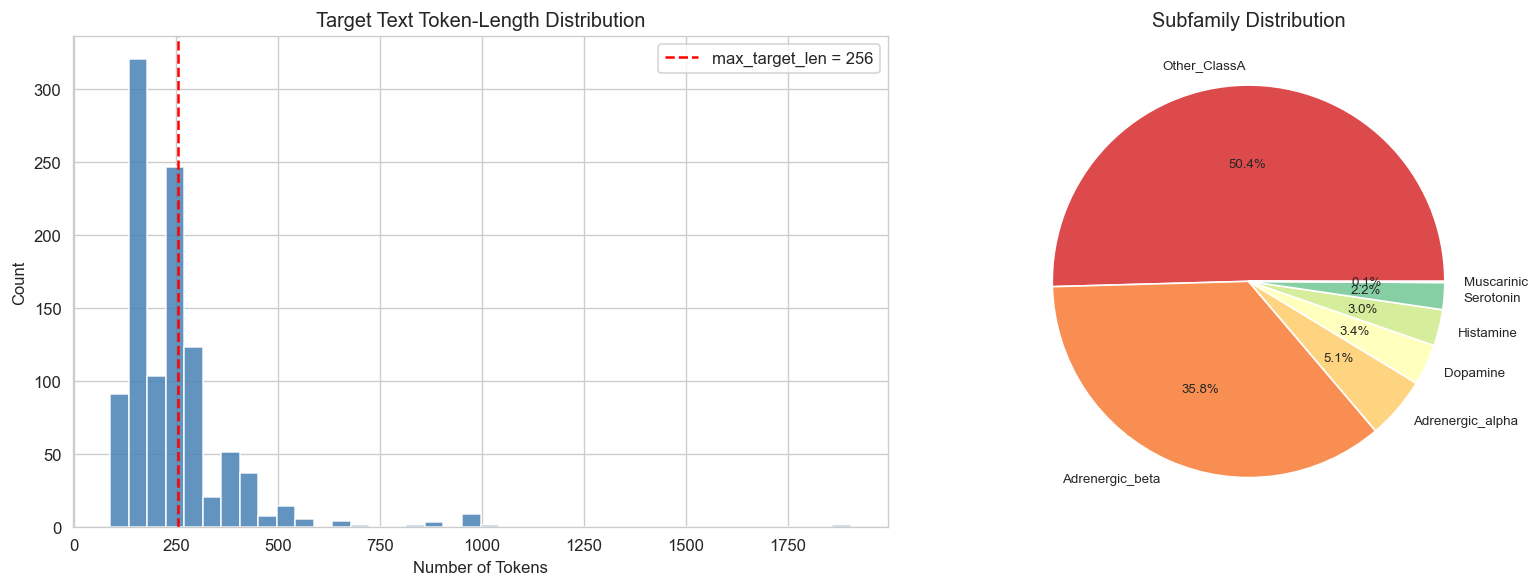


──────────────────────────────────────────────────
  Target token-length statistics
──────────────────────────────────────────────────
  • Min                   : 89
  • Max                   : 1904
  • Mean                  : 242.0
  • Median                : 226.0
  • 95th %%               : 426
  • Exceeding 256         : 336


In [8]:
# ============================================================
#  Data Overview — Token Lengths & Subfamily Distribution
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(CONFIG["llm_model"])

# Token lengths
target_lengths = np.array([
    len(tokenizer(t, truncation=False)["input_ids"])
    for t in merged["target_text"]
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Token length histogram ──
axes[0].hist(target_lengths, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(CONFIG["max_target_len"], color="red", ls="--", lw=1.5,
                label=f"max_target_len = {CONFIG['max_target_len']}")
axes[0].set_xlabel("Number of Tokens")
axes[0].set_ylabel("Count")
axes[0].set_title("Target Text Token-Length Distribution")
axes[0].legend()

# ── Right: Subfamily pie chart ──
sf_counts = merged["subfamily"].value_counts()
colors = sns.color_palette("Spectral", len(sf_counts))
wedges, texts, autotexts = axes[1].pie(
    sf_counts, labels=sf_counts.index, autopct="%1.1f%%",
    colors=colors, textprops={"fontsize": 8},
)
axes[1].set_title("Subfamily Distribution")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "data_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Statistics table ──
print(f"\n{'─'*50}")
print(f"  Target token-length statistics")
print(f"{'─'*50}")
for lbl, val in [("Min", target_lengths.min()),
                  ("Max", target_lengths.max()),
                  ("Mean", f"{target_lengths.mean():.1f}"),
                  ("Median", f"{np.median(target_lengths):.1f}"),
                  ("95th %%", f"{np.percentile(target_lengths, 95):.0f}"),
                  (f"Exceeding {CONFIG['max_target_len']}", f"{(target_lengths > CONFIG['max_target_len']).sum()}")]:
    print(f"  • {lbl:<22s}: {val}")

---

## Step 2 — Train / Validation Split & Multimodal Dataset

Split the 1 037 proteins into **train (85 %)** and **validation (15 %)**, stratified by subfamily.

Each dataset sample yields:
- `seq_embedding` — ESM2 1 280-dim vector
- `text_embedding` — SBERT 384-dim vector (subject to **modality dropout** during training)
- `labels` — tokenized target text

In [ ]:
# ============================================================
#  Train / Val Split (stratified by subfamily)
# ============================================================

indices = np.arange(len(merged))

# Handle rare classes: merge subfamilies with <2 members into "Other" for stratify
strat_labels = merged["subfamily"].values.copy()
vc = pd.Series(strat_labels).value_counts()
rare = vc[vc < 2].index.tolist()
if rare:
    print(f"Rare subfamilies merged for stratification: {rare}")
    for r in rare:
        strat_labels[strat_labels == r] = "Other_ClassA"

train_idx, val_idx = train_test_split(
    indices,
    test_size=CONFIG["val_ratio"],
    random_state=SEED,
    stratify=strat_labels,
)

print(f"{'─'*50}")
print(f"  Train : {len(train_idx):>5d} proteins")
print(f"  Val   : {len(val_idx):>5d} proteins")
print(f"{'─'*50}")
for sf in sorted(merged["subfamily"].unique()):
    n_tr = (merged.iloc[train_idx]["subfamily"] == sf).sum()
    n_va = (merged.iloc[val_idx]["subfamily"] == sf).sum()
    print(f"  • {sf:<22s}  train={n_tr:>4d}  val={n_va:>3d}")

⚠️ Rare subfamilies merged for stratification: ['Muscarinic']
──────────────────────────────────────────────────
  Train :   881 proteins
  Val   :   156 proteins
──────────────────────────────────────────────────
  • Adrenergic_alpha        train=  45  val=  8
  • Adrenergic_beta         train= 315  val= 56
  • Dopamine                train=  30  val=  5
  • Histamine               train=  26  val=  5
  • Muscarinic              train=   1  val=  0
  • Other_ClassA            train= 444  val= 79
  • Serotonin               train=  20  val=  3


In [ ]:
# ============================================================
#  Multimodal Dataset (Sequence + Text Embeddings)
# ============================================================

class MultimodalProteinDataset(Dataset):
    """
    Each sample returns:
      • seq_embedding   : (seq_dim,)   — ESM2 mean-pooled
      • text_embedding  : (text_dim,)  — SBERT (zeroed with prob. text_dropout in training)
      • labels          : (max_len,)   — tokenized target text (-100 for padding)
    """

    def __init__(self, seq_embs, text_embs, target_texts, tokenizer,
                 max_len=256, text_dropout=0.0, training=True):
        self.seq_embs      = torch.tensor(seq_embs, dtype=torch.float32)
        self.text_embs     = torch.tensor(text_embs, dtype=torch.float32)
        self.target_texts  = target_texts
        self.tokenizer     = tokenizer
        self.max_len       = max_len
        self.text_dropout  = text_dropout
        self.training      = training

    def __len__(self):
        return len(self.target_texts)

    def __getitem__(self, idx):
        seq_emb  = self.seq_embs[idx]
        text_emb = self.text_embs[idx].clone()

        # ── Modality dropout: randomly zero text embedding ──
        if self.training and self.text_dropout > 0:
            if random.random() < self.text_dropout:
                text_emb = torch.zeros_like(text_emb)

        # Tokenize target
        enc = self.tokenizer(
            self.target_texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        labels = enc["input_ids"].squeeze(0)
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "seq_embedding":  seq_emb,
            "text_embedding": text_emb,
            "labels":         labels,
        }


# ── Create datasets ───────────────────────────────────────────
train_dataset = MultimodalProteinDataset(
    seq_embeddings[train_idx],
    text_embeddings[train_idx],
    merged.iloc[train_idx]["target_text"].tolist(),
    tokenizer,
    max_len=CONFIG["max_target_len"],
    text_dropout=CONFIG["text_dropout_prob"],
    training=True,
)
val_dataset = MultimodalProteinDataset(
    seq_embeddings[val_idx],
    text_embeddings[val_idx],
    merged.iloc[val_idx]["target_text"].tolist(),
    tokenizer,
    max_len=CONFIG["max_target_len"],
    text_dropout=0.0,       # no dropout at validation
    training=False,
)

sample = train_dataset[0]
print(f"Train dataset : {len(train_dataset)} samples")
print(f"Val   dataset : {len(val_dataset)} samples")
print(f"\n  Sample shapes:")
print(f"  • seq_embedding  : {sample['seq_embedding'].shape}")
print(f"  • text_embedding : {sample['text_embedding'].shape}")
print(f"  • labels         : {sample['labels'].shape}")

✓ Train dataset : 881 samples
✓ Val   dataset : 156 samples

  Sample shapes:
  • seq_embedding  : torch.Size([1280])
  • text_embedding : torch.Size([384])
  • labels         : torch.Size([256])


---

## Step 3 — Model Architecture

### Dual Modality Projectors (LLaVA-style)
Two independent MLP projectors map each modality into Flan-T5's hidden space:

| Projector | Input | Output | Soft Tokens |
|:----------|:------|:-------|:------------|
| **Sequence Projector** | ESM2 (1 280-dim) | 512-dim × 8 | 8 tokens |
| **Text Projector** | SBERT (384-dim) | 512-dim × 4 | 4 tokens |

The 12 soft tokens are concatenated and passed as `encoder_outputs` to Flan-T5's decoder, which cross-attends to them.

### LoRA on T5 Decoder
Low-Rank Adaptation on the `q` and `v` projection matrices — only ~0.5 % of T5 params are trained.

In [12]:
# ============================================================
#  Modality Projectors (LLaVA-inspired MLP)
# ============================================================

class ModalityProjector(nn.Module):
    """
    Maps a single-modality embedding → N soft tokens in T5's hidden space.

    Architecture:
        Linear → GELU → LayerNorm → Dropout → Linear → Reshape → LayerNorm
    """

    def __init__(self, input_dim, output_dim, num_tokens):
        super().__init__()
        self.num_tokens = num_tokens
        self.output_dim = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim * 2),
            nn.GELU(),
            nn.LayerNorm(output_dim * 2),
            nn.Dropout(0.1),
            nn.Linear(output_dim * 2, output_dim * num_tokens),
        )
        self.layer_norm = nn.LayerNorm(output_dim)

    def forward(self, x):
        """(B, input_dim) → (B, num_tokens, output_dim)"""
        h = self.net(x)                                          # (B, D*N)
        h = h.view(-1, self.num_tokens, self.output_dim)         # (B, N, D)
        return self.layer_norm(h)


# ── Quick sanity check ────────────────────────────────────────
t5_hidden = 512  # flan-t5-small

seq_proj  = ModalityProjector(CONFIG["seq_embedding_dim"], t5_hidden, CONFIG["num_seq_tokens"])
text_proj = ModalityProjector(CONFIG["text_embedding_dim"], t5_hidden, CONFIG["num_text_tokens"])

dummy_seq  = torch.randn(2, CONFIG["seq_embedding_dim"])
dummy_text = torch.randn(2, CONFIG["text_embedding_dim"])

print(f"✓ Sequence Projector : {dummy_seq.shape} → {seq_proj(dummy_seq).shape}")
print(f"✓ Text Projector     : {dummy_text.shape} → {text_proj(dummy_text).shape}")
print(f"\n  Sequence projector params : {sum(p.numel() for p in seq_proj.parameters()):,}")
print(f"  Text projector params     : {sum(p.numel() for p in text_proj.parameters()):,}")

del seq_proj, text_proj  # will be created inside the full model

✓ Sequence Projector : torch.Size([2, 1280]) → torch.Size([2, 8, 512])
✓ Text Projector     : torch.Size([2, 384]) → torch.Size([2, 4, 512])

  Sequence projector params : 5,513,216
  Text projector params     : 2,496,512


In [13]:
# ============================================================
#  Full Model: Dual Projectors + Flan-T5-small + LoRA
# ============================================================

class MultimodalProt2Text(nn.Module):
    """
    Multimodal Protein → Text generation model.

    Two projectors create soft encoder tokens from sequence and text
    embeddings. These are concatenated and fed as encoder_outputs to
    the Flan-T5 decoder (with LoRA), which generates the target text.
    """

    def __init__(self, config):
        super().__init__()

        # ── Load pretrained Flan-T5 ──
        self.t5 = T5ForConditionalGeneration.from_pretrained(config["llm_model"])
        hidden_dim = self.t5.config.d_model  # 512 for flan-t5-small

        # ── Modality Projectors ──
        self.seq_projector = ModalityProjector(
            config["seq_embedding_dim"], hidden_dim, config["num_seq_tokens"],
        )
        self.text_projector = ModalityProjector(
            config["text_embedding_dim"], hidden_dim, config["num_text_tokens"],
        )
        self.total_tokens = config["num_seq_tokens"] + config["num_text_tokens"]

        # ── Apply LoRA to T5 decoder ──
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_2_SEQ_LM,
            r=config["lora_r"],
            lora_alpha=config["lora_alpha"],
            lora_dropout=config["lora_dropout"],
            target_modules=["q", "v"],
            inference_mode=False,
        )
        self.t5 = get_peft_model(self.t5, lora_config)

    def _build_encoder_outputs(self, seq_emb, text_emb):
        """Project both modalities and concatenate into soft tokens."""
        seq_tokens  = self.seq_projector(seq_emb)    # (B, 8, 512)
        text_tokens = self.text_projector(text_emb)  # (B, 4, 512)
        encoder_hidden = torch.cat([seq_tokens, text_tokens], dim=1)  # (B, 12, 512)

        attn_mask = torch.ones(
            encoder_hidden.size(0), self.total_tokens,
            dtype=torch.long, device=encoder_hidden.device,
        )
        return BaseModelOutput(last_hidden_state=encoder_hidden), attn_mask

    def forward(self, seq_embedding, text_embedding, labels=None):
        encoder_out, attn_mask = self._build_encoder_outputs(seq_embedding, text_embedding)
        return self.t5(
            encoder_outputs=encoder_out,
            attention_mask=attn_mask,
            labels=labels,
        )

    @torch.no_grad()
    def generate(self, seq_embedding, text_embedding, tokenizer,
                 max_length=256, num_beams=4):
        """Generate function text from embeddings."""
        self.eval()
        encoder_out, attn_mask = self._build_encoder_outputs(seq_embedding, text_embedding)
        gen_ids = self.t5.generate(
            encoder_outputs=encoder_out,
            attention_mask=attn_mask,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True,
            no_repeat_ngram_size=3,
        )
        return tokenizer.batch_decode(gen_ids, skip_special_tokens=True)


# ── Initialise ────────────────────────────────────────────────
model = MultimodalProt2Text(CONFIG).to(DEVICE)

# ── Summary ───────────────────────────────────────────────────
print("=" * 60)
print("  MODEL SUMMARY")
print("=" * 60)
model.t5.print_trainable_parameters()
seq_p  = sum(p.numel() for p in model.seq_projector.parameters())
text_p = sum(p.numel() for p in model.text_projector.parameters())
print(f"  • Sequence projector params : {seq_p:,}")
print(f"  • Text projector params     : {text_p:,}")
print(f"  • Total projector params    : {seq_p + text_p:,}")
print(f"  • Device                    : {DEVICE}")

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  MODEL SUMMARY
trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862
  • Sequence projector params : 5,513,216
  • Text projector params     : 2,496,512
  • Total projector params    : 8,009,728
  • Device                    : cpu


---

## Step 4 — Two-Stage Training

| Stage | What's trained | What's frozen | Purpose |
|:------|:---------------|:--------------|:--------|
| **Stage 1 — Alignment** | Sequence & Text projectors | All of T5 (incl. LoRA) | Map embeddings into T5's hidden space |
| **Stage 2 — Fine-tuning** | Projectors + LoRA adapters | Base T5 weights | Learn GPCR-specific text generation |

Both stages use **modality dropout** (20 %) — randomly zeroing the text embedding so the model learns to rely on sequence alone when necessary.

In [14]:
# ============================================================
#  Training Utilities
# ============================================================

def train_one_epoch(model, dataloader, optimizer, scheduler, device, epoch, tag):
    """Train for one epoch. Returns average loss."""
    model.train()
    total_loss, n = 0.0, 0

    for i, batch in enumerate(dataloader):
        seq_emb  = batch["seq_embedding"].to(device)
        text_emb = batch["text_embedding"].to(device)
        labels   = batch["labels"].to(device)

        loss = model(seq_emb, text_emb, labels=labels).loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss += loss.item()
        n += 1

        if (i + 1) % 20 == 0:
            print(f"    [{tag}] Epoch {epoch+1} | Batch {i+1}/{len(dataloader)} | "
                  f"Loss {loss.item():.4f}")

    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate_loss(model, dataloader, device):
    """Average validation loss."""
    model.eval()
    total_loss, n = 0.0, 0
    for batch in dataloader:
        seq_emb  = batch["seq_embedding"].to(device)
        text_emb = batch["text_embedding"].to(device)
        labels   = batch["labels"].to(device)
        total_loss += model(seq_emb, text_emb, labels=labels).loss.item()
        n += 1
    return total_loss / max(n, 1)


print("✓ Training utilities ready")

✓ Training utilities ready


In [15]:
# ============================================================
#  Stage 1 — Alignment (Projectors only, T5 frozen)
# ============================================================
print("=" * 60)
print("  STAGE 1 — Alignment (projectors only, T5 frozen)")
print("=" * 60)

# Freeze ALL T5 parameters
for p in model.t5.parameters():
    p.requires_grad = False
# Unfreeze both projectors
for p in model.seq_projector.parameters():
    p.requires_grad = True
for p in model.text_projector.parameters():
    p.requires_grad = True

trainable_s1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"  • Trainable : {trainable_s1:,} / {total_params:,} "
      f"({100*trainable_s1/total_params:.2f} %)\n")

train_loader_s1 = DataLoader(train_dataset, batch_size=CONFIG["stage1_batch"], shuffle=True)
val_loader_s1   = DataLoader(val_dataset,   batch_size=CONFIG["stage1_batch"])

projector_params = list(model.seq_projector.parameters()) + list(model.text_projector.parameters())
optimizer_s1 = torch.optim.AdamW(projector_params, lr=CONFIG["stage1_lr"], weight_decay=0.01)
total_steps  = len(train_loader_s1) * CONFIG["stage1_epochs"]
scheduler_s1 = get_linear_schedule_with_warmup(optimizer_s1,
                                                num_warmup_steps=int(0.1 * total_steps),
                                                num_training_steps=total_steps)

stage1_history = {"train_loss": [], "val_loss": []}
best_val_s1 = float("inf")

for epoch in range(CONFIG["stage1_epochs"]):
    tr_loss = train_one_epoch(model, train_loader_s1, optimizer_s1, scheduler_s1,
                              DEVICE, epoch, "S1")
    va_loss = evaluate_loss(model, val_loader_s1, DEVICE)
    stage1_history["train_loss"].append(tr_loss)
    stage1_history["val_loss"].append(va_loss)

    marker = ""
    if va_loss < best_val_s1:
        best_val_s1 = va_loss
        torch.save({
            "seq_projector":  model.seq_projector.state_dict(),
            "text_projector": model.text_projector.state_dict(),
        }, os.path.join(CONFIG["output_dir"], "projectors_stage1_best.pt"))
        marker = "  ✓ saved"

    print(f"  Epoch {epoch+1}/{CONFIG['stage1_epochs']}  "
          f"train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}{marker}")

print(f"\n✓ Stage 1 complete — best val loss: {best_val_s1:.4f}")

  STAGE 1 — Alignment (projectors only, T5 frozen)
  • Trainable : 8,009,728 / 85,659,008 (9.35 %)

    [S1] Epoch 1 | Batch 20/56 | Loss 19.9779
    [S1] Epoch 1 | Batch 40/56 | Loss 10.3953
  Epoch 1/5  train_loss=15.4625  val_loss=9.6479  ✓ saved
    [S1] Epoch 2 | Batch 20/56 | Loss 14.3635
    [S1] Epoch 2 | Batch 40/56 | Loss 12.7724
  Epoch 2/5  train_loss=12.8196  val_loss=11.0393
    [S1] Epoch 3 | Batch 20/56 | Loss 11.1295
    [S1] Epoch 3 | Batch 40/56 | Loss 8.1938
  Epoch 3/5  train_loss=9.7745  val_loss=6.6121  ✓ saved
    [S1] Epoch 4 | Batch 20/56 | Loss 6.9427
    [S1] Epoch 4 | Batch 40/56 | Loss 7.3298
  Epoch 4/5  train_loss=7.2499  val_loss=6.5810  ✓ saved
    [S1] Epoch 5 | Batch 20/56 | Loss 7.2917
    [S1] Epoch 5 | Batch 40/56 | Loss 7.1743
  Epoch 5/5  train_loss=7.2517  val_loss=6.4319  ✓ saved

✓ Stage 1 complete — best val loss: 6.4319


In [16]:
# ============================================================
#  Stage 2 — Fine-tuning (Projectors + LoRA)
# ============================================================
print("=" * 60)
print("  STAGE 2 — Fine-tuning (projectors + LoRA)")
print("=" * 60)

# Load best projectors from Stage 1
ckpt = torch.load(os.path.join(CONFIG["output_dir"], "projectors_stage1_best.pt"),
                  map_location=DEVICE, weights_only=True)
model.seq_projector.load_state_dict(ckpt["seq_projector"])
model.text_projector.load_state_dict(ckpt["text_projector"])

# Unfreeze LoRA + projectors
for name, p in model.t5.named_parameters():
    p.requires_grad = "lora" in name.lower()
for p in model.seq_projector.parameters():
    p.requires_grad = True
for p in model.text_projector.parameters():
    p.requires_grad = True

trainable_s2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  • Trainable : {trainable_s2:,} / {total_params:,} "
      f"({100*trainable_s2/total_params:.2f} %)\n")

train_loader_s2 = DataLoader(train_dataset, batch_size=CONFIG["stage2_batch"], shuffle=True)
val_loader_s2   = DataLoader(val_dataset,   batch_size=CONFIG["stage2_batch"])

optimizer_s2 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["stage2_lr"], weight_decay=0.01,
)
total_steps_s2 = len(train_loader_s2) * CONFIG["stage2_epochs"]
scheduler_s2 = get_linear_schedule_with_warmup(optimizer_s2,
                                                num_warmup_steps=int(0.1 * total_steps_s2),
                                                num_training_steps=total_steps_s2)

stage2_history = {"train_loss": [], "val_loss": []}
best_val_s2 = float("inf")
patience, patience_ctr = 5, 0

for epoch in range(CONFIG["stage2_epochs"]):
    tr_loss = train_one_epoch(model, train_loader_s2, optimizer_s2, scheduler_s2,
                              DEVICE, epoch, "S2")
    va_loss = evaluate_loss(model, val_loader_s2, DEVICE)
    stage2_history["train_loss"].append(tr_loss)
    stage2_history["val_loss"].append(va_loss)

    marker = ""
    if va_loss < best_val_s2:
        best_val_s2 = va_loss
        patience_ctr = 0
        torch.save({
            "seq_projector":  model.seq_projector.state_dict(),
            "text_projector": model.text_projector.state_dict(),
            "epoch": epoch,
            "val_loss": va_loss,
        }, os.path.join(CONFIG["output_dir"], "best_model_stage2.pt"))
        model.t5.save_pretrained(os.path.join(CONFIG["output_dir"], "t5_lora_best"))
        marker = "  ✓ saved"
    else:
        patience_ctr += 1

    print(f"  Epoch {epoch+1}/{CONFIG['stage2_epochs']}  "
          f"train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}{marker}")

    if patience_ctr >= patience:
        print(f"\n  ⚠️ Early stopping at epoch {epoch+1} (patience={patience})")
        break

print(f"\n✓ Stage 2 complete — best val loss: {best_val_s2:.4f}")

  STAGE 2 — Fine-tuning (projectors + LoRA)
  • Trainable : 8,697,856 / 85,659,008 (10.15 %)

    [S2] Epoch 1 | Batch 20/111 | Loss 7.0896
    [S2] Epoch 1 | Batch 40/111 | Loss 7.3728
    [S2] Epoch 1 | Batch 60/111 | Loss 7.1008
    [S2] Epoch 1 | Batch 80/111 | Loss 6.7111
    [S2] Epoch 1 | Batch 100/111 | Loss 6.9364
  Epoch 1/20  train_loss=6.9962  val_loss=6.2836  ✓ saved
    [S2] Epoch 2 | Batch 20/111 | Loss 6.9201
    [S2] Epoch 2 | Batch 40/111 | Loss 6.7747
    [S2] Epoch 2 | Batch 60/111 | Loss 6.5002
    [S2] Epoch 2 | Batch 80/111 | Loss 6.3218
    [S2] Epoch 2 | Batch 100/111 | Loss 6.3509
  Epoch 2/20  train_loss=6.5160  val_loss=5.7432  ✓ saved
    [S2] Epoch 3 | Batch 20/111 | Loss 6.1433
    [S2] Epoch 3 | Batch 40/111 | Loss 6.1823
    [S2] Epoch 3 | Batch 60/111 | Loss 6.0444
    [S2] Epoch 3 | Batch 80/111 | Loss 6.0006
    [S2] Epoch 3 | Batch 100/111 | Loss 6.0732
  Epoch 3/20  train_loss=6.0239  val_loss=5.5367  ✓ saved
    [S2] Epoch 4 | Batch 20/111 | Loss 

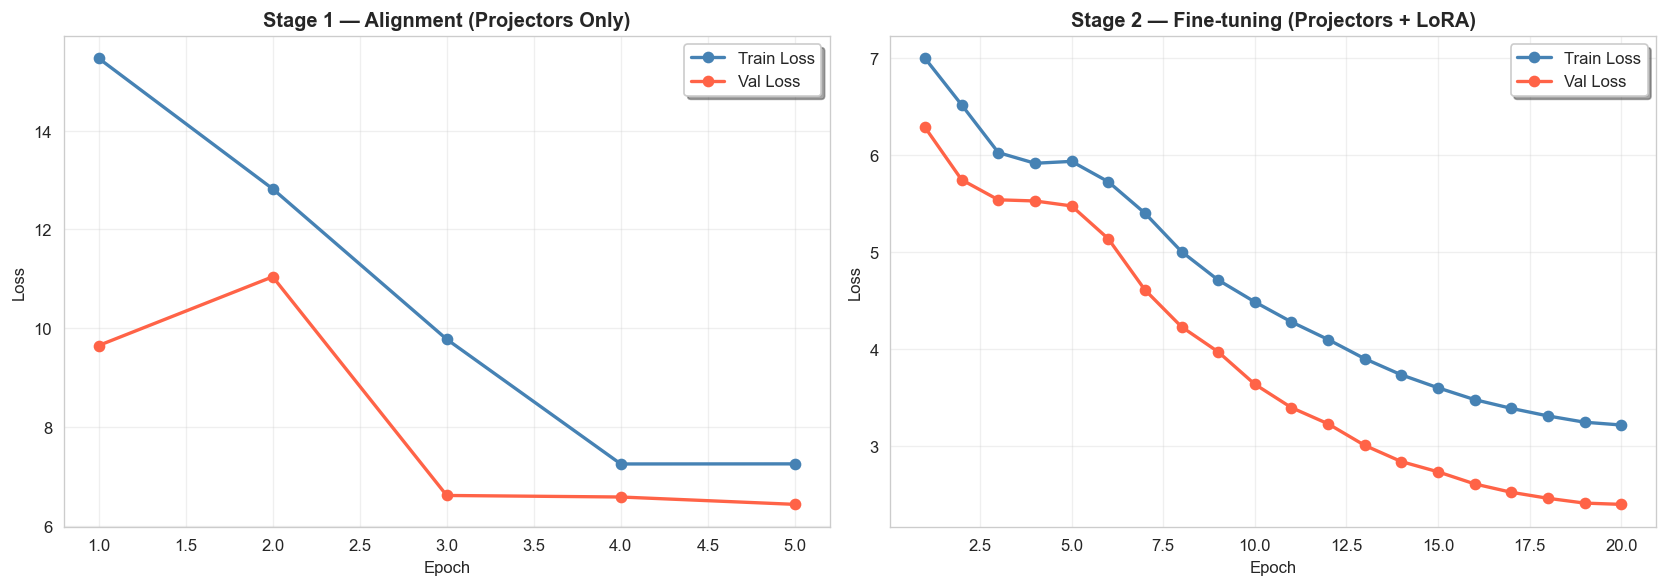

✓ Training curves saved


In [17]:
# ============================================================
#  Training Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title in [
    (axes[0], stage1_history, "Stage 1 — Alignment (Projectors Only)"),
    (axes[1], stage2_history, "Stage 2 — Fine-tuning (Projectors + LoRA)"),
]:
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], "o-", color="steelblue", label="Train Loss", lw=2)
    ax.plot(epochs, hist["val_loss"],   "o-", color="tomato",    label="Val Loss",   lw=2)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "training_curves.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✓ Training curves saved")

---

## Step 5 — Evaluation (BLEU, ROUGE & Subfamily Accuracy)

Generate function descriptions for all **validation** proteins and evaluate:
- **BLEU** (1–4) — n-gram overlap precision
- **ROUGE** (1, 2, L) — longest common subsequence / recall
- **Subfamily accuracy** — extracted from the generated `SUBFAMILY:` line

In [18]:
# ============================================================
#  Load Best Model & Generate on Validation Set
# ============================================================

# Load best checkpoint
best = torch.load(os.path.join(CONFIG["output_dir"], "best_model_stage2.pt"),
                  map_location=DEVICE, weights_only=True)
model.seq_projector.load_state_dict(best["seq_projector"])
model.text_projector.load_state_dict(best["text_projector"])
print(f" Loaded best model from epoch {best['epoch']+1} "
      f"(val_loss={best['val_loss']:.4f})")

# ── Generate in mini-batches ──
model.eval()
val_seq  = torch.tensor(seq_embeddings[val_idx],  dtype=torch.float32).to(DEVICE)
val_text = torch.tensor(text_embeddings[val_idx], dtype=torch.float32).to(DEVICE)
val_gt   = merged.iloc[val_idx]["target_text"].tolist()

generated_texts = []
B = 16
for i in range(0, len(val_idx), B):
    texts = model.generate(
        val_seq[i:i+B], val_text[i:i+B],
        tokenizer, max_length=CONFIG["max_target_len"],
    )
    generated_texts.extend(texts)

print(f" Generated {len(generated_texts)} validation descriptions")

 Loaded best model from epoch 20 (val_loss=2.3955)
 Generated 156 validation descriptions


In [19]:
# ============================================================
#  BLEU & ROUGE Metrics
# ============================================================

bleu_metric  = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

bleu_res  = bleu_metric.compute(predictions=generated_texts,
                                 references=[[r] for r in val_gt])
rouge_res = rouge_metric.compute(predictions=generated_texts,
                                  references=val_gt)

# ── Pretty table ──
metrics_table = pd.DataFrame([
    {"Metric": "BLEU",     "Score": f"{bleu_res['bleu']:.4f}"},
    {"Metric": "BLEU-1",   "Score": f"{bleu_res['precisions'][0]:.4f}"},
    {"Metric": "BLEU-2",   "Score": f"{bleu_res['precisions'][1]:.4f}"},
    {"Metric": "BLEU-3",   "Score": f"{bleu_res['precisions'][2]:.4f}"},
    {"Metric": "BLEU-4",   "Score": f"{bleu_res['precisions'][3]:.4f}"},
    {"Metric": "ROUGE-1",  "Score": f"{rouge_res['rouge1']:.4f}"},
    {"Metric": "ROUGE-2",  "Score": f"{rouge_res['rouge2']:.4f}"},
    {"Metric": "ROUGE-L",  "Score": f"{rouge_res['rougeL']:.4f}"},
    {"Metric": "ROUGE-Lsum", "Score": f"{rouge_res['rougeLsum']:.4f}"},
])

print("=" * 55)
print("  EVALUATION METRICS — Validation Set")
print("=" * 55)
for _, row in metrics_table.iterrows():
    print(f"  • {row['Metric']:<14s}: {row['Score']}")

# Save
all_metrics = {
    "bleu": bleu_res["bleu"],
    **{f"bleu_{i+1}": bleu_res["precisions"][i] for i in range(4)},
    **{k: v for k, v in rouge_res.items()},
}
with open(os.path.join(CONFIG["output_dir"], "eval_metrics.json"), "w") as f:
    json.dump(all_metrics, f, indent=2)
print("\n✓ Metrics saved to eval_metrics.json")

  EVALUATION METRICS — Validation Set
  • BLEU          : 0.1223
  • BLEU-1        : 0.5298
  • BLEU-2        : 0.2875
  • BLEU-3        : 0.1725
  • BLEU-4        : 0.1176
  • ROUGE-1       : 0.3401
  • ROUGE-2       : 0.1173
  • ROUGE-L       : 0.2625
  • ROUGE-Lsum    : 0.2723

✓ Metrics saved to eval_metrics.json


In [20]:
# ============================================================
#  Side-by-Side: Ground Truth vs Generated
# ============================================================

np.random.seed(42)
show_n = min(8, len(generated_texts))
sample_ids = np.random.choice(len(generated_texts), size=show_n, replace=False)

for k, idx in enumerate(sample_ids):
    row = merged.iloc[val_idx[idx]]
    print(f"\n{'━'*70}")
    print(f"  Example {k+1}  │  Protein: {row['ID']}  │  Subfamily: {row['subfamily']}")
    print(f"{'━'*70}")
    print(f"\n  ┌─── GROUND TRUTH {'─'*49}")
    for line in val_gt[idx].split("\n"):
        print(f"  │ {line}")
    print(f"  └{'─'*66}")
    print(f"\n  ┌─── GENERATED {'─'*51}")
    for line in generated_texts[idx].split("\n"):
        print(f"  │ {line}")
    print(f"  └{'─'*66}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Example 1  │  Protein: A0A6P8RF16  │  Subfamily: Adrenergic_beta
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌─── GROUND TRUTH ─────────────────────────────────────────────────
  │ SUBFAMILY: Adrenergic_beta
  │ GO TERMS: early endosome [GO:0005769]; plasma membrane [GO:0005886]; beta1-adrenergic receptor activity [GO:0004940]; adenylate cyclase-activating adrenergic receptor signaling pathway [GO:0071880]; norepinephrine-epinephrine-mediated vasodilation involved in regulation of systemic arterial blood pressure [GO:0002025]; positive regulation of heart contraction [GO:0045823]; positive regulation of MAPK cascade [GO:0043410]
  │ KEYWORDS: Cell membrane; Disulfide bond; Endosome; G-protein coupled receptor; Glycoprotein; Lipoprotein; Membrane; Palmitate; Phosphoprotein; Receptor; Reference proteome; Transducer; Transmembrane; Transmembrane helix
  │ PROTEIN: Beta-1 adrenergic rece

---

## Step 6 — Inference on New (Unlabeled) Sequences

For sequences that have **no text metadata**, we pass a **zero text embedding** — the model learned to handle this gracefully via modality dropout (20 % of training samples had zeroed text).

This is the key advantage of the multimodal architecture: it leverages text when available but can still generate function descriptions from sequence embeddings alone.

✓ Loaded unlabeled embeddings: (961, 1281)
  Generating for 961 sequences (sequence-only mode) ...
    Processed 320/961
    Processed 640/961
    Processed 960/961

✓ Generated 961 function descriptions
✓ Saved to prot2func_gpcr_output/predicted_functions.csv


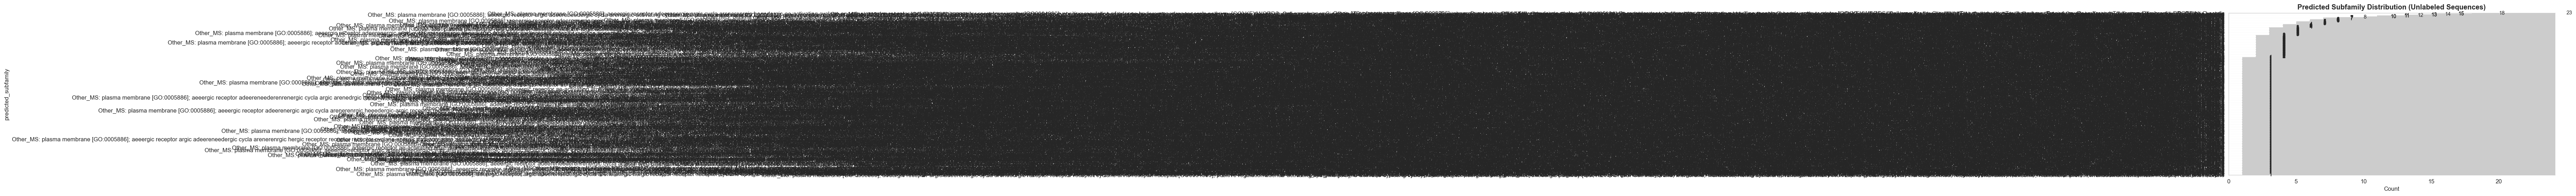


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SAMPLE PREDICTIONS — Unlabeled Sequences
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌─── P07550  │  Predicted: Other_MS: plasma membrane [GO:0005886]; adeeergic receptor ae-activating argic arenrgic cycla cyclane apeereneederenrgic receptor receptor heeerine receptor receptor [GO0004380]; positive regulation of adenaese-ae receptor cycle-cycla-arenergic pathway [GO; KEYWORDORDS: Cell membrane; G-protein; Transanmbrane; Transmembranlix PROTEIN: G; Transduce; Rembran; Transembranor; Reeembrmee; Membrane-protein receptor; Transome; Transmbranmbrme; Transcepte; Referenceeelixprotein; Reprotein; Reference; Transambranule; Diseeore; Gmbranprotein; Dismbran-protein coupled; Transombranrgic; Relixanlix hembranmee herenmbranrenelix
  │ SUBFAMILY: Other_MS: plasma membrane [GO:0005886]; adeeergic receptor ae-activating argic arenrgic cycla cyclane apeereneederenrgic receptor receptor heeerine

In [ ]:
# ============================================================
#  Inference on Unlabeled Sequences (sequence-only mode)
# ============================================================

unlabeled_path = "../data/processed/data_esm2_mean_pooling_without_id.csv"

if os.path.exists(unlabeled_path):
    unlabeled_df = pd.read_csv(unlabeled_path)
    print(f"✓ Loaded unlabeled embeddings: {unlabeled_df.shape}")

    # Handle ID column
    if "uniref_id" in unlabeled_df.columns:
        ul_ids = unlabeled_df["uniref_id"].tolist()
        unlabeled_df = unlabeled_df.drop(columns=["uniref_id"])
    elif "Unnamed: 0" in unlabeled_df.columns:
        ul_ids = unlabeled_df["Unnamed: 0"].tolist()
        unlabeled_df = unlabeled_df.drop(columns=["Unnamed: 0"])
    else:
        ul_ids = [f"seq_{i}" for i in range(len(unlabeled_df))]

    ul_seq_embs = unlabeled_df.values.astype(np.float32)

    # ── Generate with zero text embeddings (sequence-only mode) ──
    model.eval()
    all_preds = []
    B = 16

    print(f"  Generating for {len(ul_seq_embs)} sequences (sequence-only mode) ...")
    for i in range(0, len(ul_seq_embs), B):
        batch_seq  = torch.tensor(ul_seq_embs[i:i+B], dtype=torch.float32).to(DEVICE)
        batch_text = torch.zeros(batch_seq.size(0), CONFIG["text_embedding_dim"],
                                 dtype=torch.float32).to(DEVICE)

        texts = model.generate(batch_seq, batch_text, tokenizer,
                               max_length=CONFIG["max_target_len"])
        all_preds.extend(texts)

        if (i // B + 1) % 20 == 0:
            print(f"    Processed {min(i+B, len(ul_seq_embs))}/{len(ul_seq_embs)}")

    # Build results
    results_df = pd.DataFrame({
        "query_id":            ul_ids[:len(all_preds)],
        "predicted_subfamily": [extract_subfamily(t) for t in all_preds],
        "generated_text":      all_preds,
    })
    results_df.to_csv(os.path.join(CONFIG["output_dir"], "predicted_functions.csv"),
                      index=False)

    print(f"\nGenerated {len(all_preds)} function descriptions")
    print(f"Saved to {CONFIG['output_dir']}/predicted_functions.csv")

    # ── Show examples ──
    print(f"\n{'━'*70}")
    print(f"  SAMPLE PREDICTIONS — Unlabeled Sequences")
    print(f"{'━'*70}")
    for i in range(min(5, len(results_df))):
        r = results_df.iloc[i]
        print(f"\n  ┌─── {r['query_id']}  │  Predicted: {r['predicted_subfamily']}")
        for line in r["generated_text"].split("\n"):
            print(f"  │ {line}")
        print(f"  └{'─'*66}")
else:
    print(f" File not found: {unlabeled_path}")
    print("   Skipping unlabeled inference.")

---

## Step 7 — Save Final Model & Inference Demo

In [24]:
# ============================================================
#  Save All Artifacts
# ============================================================

torch.save({
    "seq_projector":  model.seq_projector.state_dict(),
    "text_projector": model.text_projector.state_dict(),
}, os.path.join(CONFIG["output_dir"], "projectors_final.pt"))

model.t5.save_pretrained(os.path.join(CONFIG["output_dir"], "t5_lora_final"))
tokenizer.save_pretrained(os.path.join(CONFIG["output_dir"], "tokenizer"))

with open(os.path.join(CONFIG["output_dir"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

with open(os.path.join(CONFIG["output_dir"], "training_history.json"), "w") as f:
    json.dump({"stage1": stage1_history, "stage2": stage2_history}, f, indent=2)

print("=" * 55)
print("  SAVED ARTIFACTS")
print("=" * 55)
for name in sorted(os.listdir(CONFIG["output_dir"])):
    full = os.path.join(CONFIG["output_dir"], name)
    if os.path.isfile(full):
        mb = os.path.getsize(full) / 1e6
        print(f"  • {name:<40s} {mb:>7.2f} MB")
    else:
        print(f"  • {name + '/':<40s} (directory)")

  SAVED ARTIFACTS
  • best_model_stage2.pt                       32.05 MB
  • comparison_gen_vs_retrieval.csv             0.09 MB
  • config.json                                 0.00 MB
  • confusion_matrix.png                       37.07 MB
  • data_overview.png                           0.08 MB
  • eval_metrics.json                           0.00 MB
  • gen_vs_retrieval.png                        0.07 MB
  • predicted_functions.csv                     1.03 MB
  • predicted_subfamily_dist.png                5.10 MB
  • projectors_final.pt                        32.05 MB
  • projectors_stage1_best.pt                  32.05 MB
  • t5_lora_best/                            (directory)
  • t5_lora_final/                           (directory)
  • tokenizer/                               (directory)
  • training_curves.png                         0.23 MB
  • training_history.json                       0.00 MB


In [25]:
# ============================================================
#  Inference Demo — Single Protein
# ============================================================

def predict_function(model, tokenizer, seq_emb, text_emb=None, device=DEVICE):
    """
    Predict function text for a single protein.

    Args:
        seq_emb  : (1280,) numpy array — ESM2 embedding
        text_emb : (384,) numpy array — SBERT embedding (optional, zeros if None)

    Returns:
        Generated function description string.
    """
    model.eval()
    s = torch.tensor(seq_emb, dtype=torch.float32).unsqueeze(0).to(device)
    if text_emb is not None:
        t = torch.tensor(text_emb, dtype=torch.float32).unsqueeze(0).to(device)
    else:
        t = torch.zeros(1, CONFIG["text_embedding_dim"], dtype=torch.float32).to(device)
    return model.generate(s, t, tokenizer, max_length=256, num_beams=4)[0]


# ── Demo: with text ──
demo_idx = np.random.randint(0, len(seq_embeddings))
demo_row = merged.iloc[demo_idx]

print("━" * 70)
print(f"  INFERENCE DEMO — {demo_row['ID']}  │  {demo_row['subfamily']}")
print("━" * 70)

print("\n  ┌─── WITH text embedding (multimodal)")
pred_mm = predict_function(model, tokenizer,
                           seq_embeddings[demo_idx], text_embeddings[demo_idx])
for line in pred_mm.split("\n"):
    print(f"  │ {line}")
print(f"  └{'─'*66}")

print("\n  ┌─── WITHOUT text embedding (sequence-only)")
pred_seq = predict_function(model, tokenizer,
                            seq_embeddings[demo_idx], text_emb=None)
for line in pred_seq.split("\n"):
    print(f"  │ {line}")
print(f"  └{'─'*66}")

print(f"\n  ┌─── GROUND TRUTH")
for line in demo_row["target_text"].split("\n"):
    print(f"  │ {line}")
print(f"  └{'─'*66}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INFERENCE DEMO — A0A7J6BUC9  │  Adrenergic_beta
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌─── WITH text embedding (multimodal)
  │ SUBFAMILY: Other_MS: plasma membrane [GO:0005886]; adeeergic receptor aeerenergic pathway argic arenrgic cycla-argic receptor receptor cyclanrgic heeedrgic receptor [GO0004380]; positive regulation adenane-activating apeerine arine cycle-aederenrgic receptor activity a-activane pathway cycling-areneehergicing-mediated of ahe pathwaying pathwaying-cyclandedrenerine [GO; KEYWORDS: Cell membrane; G-protein; Transmembrane; Transduce; Rembranmbranlix PROTEIN: G-heergic
  └──────────────────────────────────────────────────────────────────

  ┌─── WITHOUT text embedding (sequence-only)
  │ SUBFAMILY: Other_MS: plasma membrane [GO:0005886]; aeeergic receptor argic adeereneedergic cycla arenerenrgic hergic receptor receptor receptor cyclane arine apeerine [GO000

## Summary

| Item | Detail |
|------|--------|
| **Task** | Protein embedding → structured function-text generation |
| **Input (Sequence)** | ESM-2 mean-pooled embeddings (1 280-d) → **8 soft tokens** |
| **Input (Text)** | Sentence-BERT embeddings (384-d) → **4 soft tokens** |
| **Modality Dropout** | 20 % probability of zeroing text embedding during training |
| **Decoder** | `google/flan-t5-small` (80 M params) with LoRA (r = 16) |
| **Training** | Stage 1 — projector alignment (5 ep, lr = 1e-3) · Stage 2 — projectors + LoRA (≤ 20 ep, lr = 3e-4, early stop pat = 5) |
| **Target** | SUBFAMILY · FUNCTION · GO TERMS · KEYWORDS · PROTEIN NAME |
| **Metrics** | BLEU-1 / -4, ROUGE-1 / -2 / -L, subfamily extraction accuracy |

### Architecture — Multimodal Dual-Projector (LLaVA-style)

```
ESM-2  (1280) ──▶ Seq  Projector ──▶ 8 tokens (512-d) ─┐
                                                         ├──▶ Flan-T5 Decoder (LoRA) ──▶ Text
SBERT  (384)  ──▶ Text Projector ──▶ 4 tokens (512-d) ─┘
```

**Key design choices**
- **Dual modality inputs** — the model sees *both* the protein sequence structure (ESM-2) and existing text annotations (SBERT) as soft tokens
- **Modality dropout** — during training, text embeddings are randomly zeroed so the model remains robust in **sequence-only inference** on unlabeled proteins
- **Two-stage curriculum** — Stage 1 warms up the projectors while T5 is frozen; Stage 2 fine-tunes everything with LoRA
- Saved artifacts in `prot2func_gpcr_output/`